In [1]:
import numpy as np
import pandas as pd

import pingouin as pg

import seaborn as sns
from matplotlib import pyplot as plt

# fig5b

Fig. 5b — Paired t-tests: EV vs. REV
  Phase: full_safe
               T  dof alternative     p_val           CI95   cohen_d     power   BF10
T_test  0.087009   13   two-sided  0.931991  [-0.11, 0.12]  0.032629  0.051473  0.271

  Phase: full_shock
               T  dof alternative     p_val          CI95   cohen_d  power     BF10
T_test  6.561928   13   two-sided  0.000018  [0.17, 0.33]  2.084931    1.0  1291.75

  Phase: shock_observation
               T  dof alternative     p_val          CI95   cohen_d     power     BF10
T_test  5.414704   13   two-sided  0.000118  [0.14, 0.31]  1.724192  0.999963  248.619

phase
  Contrast           A                  B  Paired  Parametric         T   dof alternative     p_unc    p_corr p_adjust    BF10     cohen
0    phase   full_safe         full_shock    True        True -3.545925  13.0   two-sided  0.003584  0.010753     holm  13.289 -1.120815
1    phase   full_safe  shock_observation    True        True -2.414307  13.0   two-sided  0.031237 

/tmp/ipykernel_3500507/2271887922.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylabel='explained variance (EV / REV)',


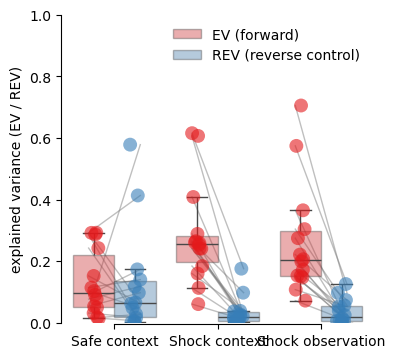

In [4]:
df_ev = pd.read_parquet('Fig5b.parquet')
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

# Paired animal lines for each phase
for phase, x_pos in [('full_safe', [-0.25, 0.25]),
                      ('full_shock', [0.75, 1.25]),
                      ('shock_observation', [1.75, 2.25])]:
    for pair in np.array(df_ev.query("phase == '{}'".format(phase))
                               .set_index(['rat', 'direction'])
                               .unstack()['explained_variance']):
        ax.plot(x_pos, pair, color='grey', lw=1.0, alpha=0.5)

sns.boxplot(y='explained_variance', x='phase', hue='direction',
            palette='Set1',
            order=['full_safe', 'full_shock', 'shock_observation'],
            boxprops=dict(alpha=0.4), fliersize=0.0,
            data=df_ev, ax=ax)
sns.stripplot(y='explained_variance', x='phase', hue='direction',
              palette='Set1',
              order=['full_safe', 'full_shock', 'shock_observation'],
              size=10, alpha=0.6, dodge=True,
              data=df_ev, ax=ax)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], ['EV (forward)', 'REV (reverse control)'], frameon=False)
ax.set(ylabel='explained variance (EV / REV)',
       xlabel='',
       xticklabels=['Safe context', 'Shock context', 'Shock observation'],
       ylim=(0, 1))
sns.despine(offset=True, trim=True)


# Paired t-test: EV vs. REV within each phase
print("Fig. 5b — Paired t-tests: EV vs. REV")
for phase in np.unique(df_ev.phase):
    results = pg.ttest(
        df_ev.query("phase == '{}' and direction == 'forward'".format(phase))['explained_variance'],
        df_ev.query("phase == '{}' and direction == 'reverse'".format(phase))['explained_variance'],
        paired=True)
    
    # results = pg.wilcoxon(
    #     df_ev.query("phase == '{}' and direction == 'forward'".format(phase))['explained_variance'],
    #     df_ev.query("phase == '{}' and direction == 'reverse'".format(phase))['explained_variance'])
    
    print("  Phase: {}".format(phase))
    print(results.to_string())
    print()

results = pg.pairwise_tests(
    data=df_ev.query("direction == 'forward'".format(phase)), 
    dv='explained_variance', padjust='holm', within='phase',
    subject='rat', correction=False, effsize='cohen',
    # parametric=False
)

print("phase")
print(results.to_string())
print()

# fig5c

/tmp/ipykernel_3500507/2579246987.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='explained_variance', x='phase',
/tmp/ipykernel_3500507/2579246987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(y='explained_variance', x='phase',
/tmp/ipykernel_3500507/2579246987.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylabel='explained variance (EV)',
/tmp/ipykernel_3500507/2579246987.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=

Fig. 5c — Paired t-tests: EV safe vs. shock context, by SWR-originating subregion
  SWR subregion: dCA1
               T  dof alternative     p_val            CI95  cohen_d     power   BF10
T_test -2.748876   10   two-sided  0.020518  [-0.24, -0.02]  0.91577  0.781343  3.409

  SWR subregion: iCA1
               T  dof alternative     p_val            CI95   cohen_d     power    BF10
T_test -4.114568    9   two-sided  0.002619  [-0.21, -0.06]  1.477755  0.985125  18.408

  SWR subregion: vCA1
               T  dof alternative     p_val            CI95   cohen_d     power   BF10
T_test -2.627002   13   two-sided  0.020906  [-0.17, -0.02]  0.694885  0.671821  3.124



/tmp/ipykernel_3500507/2579246987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(y='explained_variance', x='phase',
/tmp/ipykernel_3500507/2579246987.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylabel='explained variance (EV)',


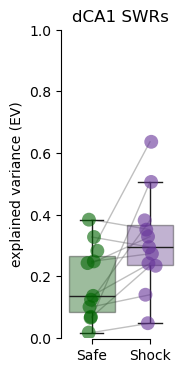

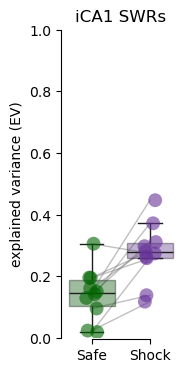

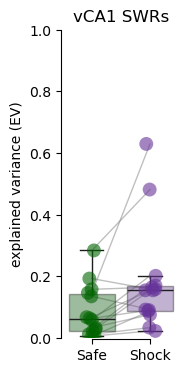

In [5]:
df_ev_swr = pd.read_parquet('Fig5c.parquet')

for area in ['dCA1', 'iCA1', 'vCA1']:
    fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))

    # Paired animal lines
    for pair in np.array(
            df_ev_swr.query("direction == 'forward' and area == '{}'".format(area))
                     .set_index(['rat', 'phase'])
                     .unstack()['explained_variance']):
        ax.plot([0, 1], pair, color='grey', lw=1.0, alpha=0.5)

    sns.boxplot(y='explained_variance', x='phase',
                order=['full_safe', 'full_shock'],
                palette=['darkgreen', 'rebeccapurple'],
                boxprops=dict(alpha=0.4), fliersize=0.0,
                data=df_ev_swr.query("direction == 'forward' and area == '{}'".format(area)), ax=ax)
    sns.stripplot(y='explained_variance', x='phase',
                  order=['full_safe', 'full_shock'],
                  palette=['darkgreen', 'rebeccapurple'],
                  size=10, alpha=0.6, dodge=False,
                  data=df_ev_swr.query("direction == 'forward' and area == '{}'".format(area)), ax=ax)

    ax.set(ylabel='explained variance (EV)',
           xlabel='', xticklabels=['Safe', 'Shock'],
           ylim=(0, 1), title='{} SWRs'.format(area))
    sns.despine(offset=True, trim=True)

print("Fig. 5c — Paired t-tests: EV safe vs. shock context, by SWR-originating subregion")
for area in np.unique(df_ev_swr.area):
    results = pg.ttest(
        df_ev_swr.query("phase == 'full_safe'  and direction == 'forward' and area == '{}'".format(area))['explained_variance'],
        df_ev_swr.query("phase == 'full_shock' and direction == 'forward' and area == '{}'".format(area))['explained_variance'],
        paired=True)

    # results = pg.wilcoxon(
    #     df_ev_swr.query("phase == 'full_safe'  and direction == 'forward' and area == '{}'".format(area))['explained_variance'],
    #     df_ev_swr.query("phase == 'full_shock' and direction == 'forward' and area == '{}'".format(area))['explained_variance'])

    print("  SWR subregion: {}".format(area))
    print(results.to_string())
    print()



# Fig5d

/tmp/ipykernel_3500507/3564780602.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='explained_variance', x='phase',
/tmp/ipykernel_3500507/3564780602.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(y='explained_variance', x='phase',
/tmp/ipykernel_3500507/3564780602.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylabel='explained variance (EV)',
/tmp/ipykernel_3500507/3564780602.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=

Fig. 5d — Paired t-tests: EV safe vs. shock context, by neuron-pair subregion
  Subregion: dorsal
               T  dof alternative    p_val           CI95   cohen_d    power   BF10
T_test -1.673367    4   two-sided  0.16957  [-0.38, 0.09]  0.670671  0.21327  0.949

  Subregion: intermediate
               T  dof alternative     p_val            CI95  cohen_d     power   BF10
T_test -3.104692    8   two-sided  0.014562  [-0.14, -0.02]  1.00475  0.751928  4.724

  Subregion: ventral
             T  dof alternative     p_val           CI95   cohen_d     power   BF10
T_test -1.4693    7   two-sided  0.185207  [-0.32, 0.07]  0.653053  0.358333  0.746

Fig. 5e — Independent t-tests: ΔEV (shock − safe) by recall status
  Subregion: dorsal
     U_val alternative  p_val       RBC      CLES
MWU    4.0   two-sided    0.8  0.333333  0.666667

  Subregion: intermediate
     U_val alternative     p_val  RBC  CLES
MWU    1.0   two-sided  0.031746 -0.9  0.05

  Subregion: ventral
     U_val alternati

/tmp/ipykernel_3500507/3564780602.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylabel='ΔEV (shock − safe)',


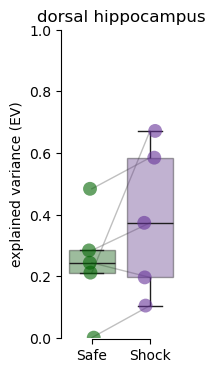

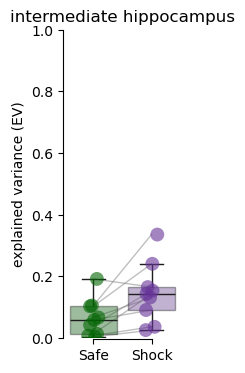

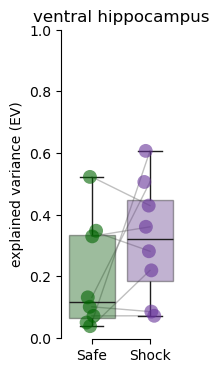

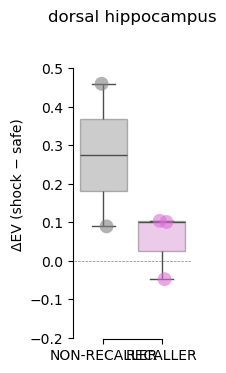

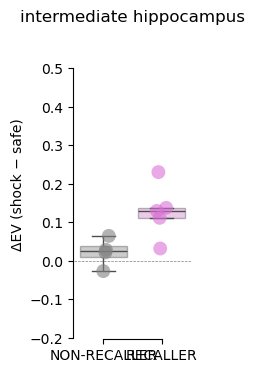

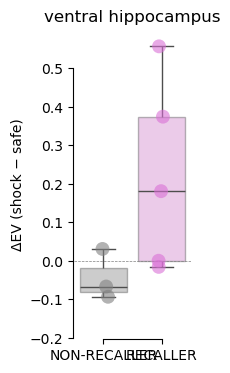

In [7]:
df_ev_cell = pd.read_parquet('Fig5d.parquet')

for area in ['dorsal', 'intermediate', 'ventral']:
    fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))

    for pair in np.array(
            df_ev_cell.query("direction == 'forward' and area == '{}'".format(area))
                      .set_index(['rat', 'phase'])
                      .unstack()['explained_variance']):
        ax.plot([0, 1], pair, color='grey', lw=1.0, alpha=0.5)

    sns.boxplot(y='explained_variance', x='phase',
                order=['full_safe', 'full_shock'],
                palette=['darkgreen', 'rebeccapurple'],
                boxprops=dict(alpha=0.4), fliersize=0.0,
                data=df_ev_cell.query("direction == 'forward' and area == '{}'".format(area)), ax=ax)
    sns.stripplot(y='explained_variance', x='phase',
                  order=['full_safe', 'full_shock'],
                  palette=['darkgreen', 'rebeccapurple'],
                  size=10, alpha=0.6, dodge=False,
                  data=df_ev_cell.query("direction == 'forward' and area == '{}'".format(area)), ax=ax)

    ax.set(ylabel='explained variance (EV)',
           xlabel='', xticklabels=['Safe', 'Shock'],
           ylim=(0, 1), title='{} hippocampus'.format(area))
    sns.despine(offset=True, trim=True)



tmp_ev = (df_ev_cell.query("direction == 'forward'")
          .set_index(['rat', 'area', 'phase'])
          .unstack())
tmp_ev['delta']    = np.diff(tmp_ev.explained_variance)        # EV(shock) − EV(safe)
tmp_ev['learning'] = tmp_ev['context_learning', 'full_shock']
tmp_ev = tmp_ev[['delta', 'learning']].reset_index().droplevel(1, axis=1)

for area in ['dorsal', 'intermediate', 'ventral']:
    fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))
    sns.boxplot(y='delta', x='learning',
                order=['not learned', 'learned'],
                palette=['grey', 'orchid'],
                boxprops=dict(alpha=0.4), fliersize=0.0,
                data=tmp_ev.query("area == '{}'".format(area)), ax=ax)
    sns.stripplot(y='delta', x='learning',
                  order=['not learned', 'learned'],
                  palette=['grey', 'orchid'],
                  size=10, alpha=0.6, dodge=False,
                  data=tmp_ev.query("area == '{}'".format(area)), ax=ax)

    ax.axhline(0, ls='--', lw=0.5, color='grey')
    ax.set(ylabel='ΔEV (shock − safe)',
           xlabel='',
           xticklabels=['NON-RECALLER', 'RECALLER'],
           ylim=(-0.2, 0.6),
           title='{} hippocampus'.format(area))
    sns.despine(offset=True, trim=True)

# Fig. 5d: paired t-test, EV safe vs. shock per neuron-pair subregion
print("Fig. 5d — Paired t-tests: EV safe vs. shock context, by neuron-pair subregion")
for area in np.unique(df_ev_cell.area):
    results = pg.ttest(
        df_ev_cell.query("phase == 'full_safe'  and direction == 'forward' and area == '{}'".format(area))['explained_variance'],
        df_ev_cell.query("phase == 'full_shock' and direction == 'forward' and area == '{}'".format(area))['explained_variance'],
        paired=True)
    print("  Subregion: {}".format(area))
    print(results.to_string())
    print()

# Fig. 5e: independent t-test, ΔEV by recall status per subregion
tmp_ev = (df_ev_cell.query("direction == 'forward'")
          .set_index(['rat', 'area', 'phase'])
          .unstack())
tmp_ev['delta']    = np.diff(tmp_ev.explained_variance)
tmp_ev['learning'] = tmp_ev['context_learning', 'full_shock']
tmp_ev = tmp_ev[['delta', 'learning']].reset_index().droplevel(1, axis=1)

print("Fig. 5e — Independent t-tests: ΔEV (shock − safe) by recall status")
for area in np.unique(tmp_ev.area):
    results = pg.ttest(
        tmp_ev.query("learning == 'not learned' and area == '{}'".format(area))['delta'],
        tmp_ev.query("learning == 'learned'     and area == '{}'".format(area))['delta'],
        paired=False)

    # results = pg.mwu(
    #     tmp_ev.query("learning == 'not learned' and area == '{}'".format(area))['delta'],
    #     tmp_ev.query("learning == 'learned'     and area == '{}'".format(area))['delta'])
    
    print("  Subregion: {}".format(area))
    print(results.to_string())
    print()